In [49]:
import os
import numpy as np
import networkx as nx

from src.OrganoidMesh import OrganoidMesh
from src.cell_graph_functions import *
from src.nuclei_to_mesh_projection import *
from src.mesh_analysis import *
from src.crypt_extraction import *
from src.organoid_plotting import *

In [50]:
# ---------------------------------------------------------------------------
# Configuration / paths
# ---------------------------------------------------------------------------

data_dir = '../NicoleData/20250929/fractal_output'

# --- path to your cell nucleus table ---
CELLS_CSV = "../NicoleData/features_csv/features/cell_types_class.csv"   # <-- adjust

timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "A06"
round_name = "0_fused_zillum_registered"
organoid_id = 19 #19 # example


# timepoint = "day4"
# zarr_name = "r0.zarr"
# well = "A05"
# round_name = "0_fused_zillum_registered"
# organoid_id = 79


# timepoint = "day4"
# zarr_name = "r0.zarr"
# well = "B01"
# round_name = "0_fused_zillum_registered"
# organoid_id = 83


# timepoint = "day4"
# zarr_name = "r0.zarr"
# well = "A04"
# round_name = "0_fused_zillum_registered"
# organoid_id = 89


mesh_path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class/{organoid_id}.vtp"
cells_df = pd.read_csv(CELLS_CSV)


marker_names = ['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB',
                'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']

### Project nuclei to mesh and tessellate

In [51]:
organoid_id = os.path.splitext(os.path.basename(mesh_path))[0]
label_uid = f"{timepoint}_{well}_{organoid_id}"

nuclei_df_org = cells_df[cells_df["label_uid"] == label_uid].copy()

# 1) load membrane mesh as an OrganoidMesh
mesh = OrganoidMesh(mesh_path)

# 2) extract per-cell attributes
nuclei_xyz, markers_bin = extract_cell_attributes(nuclei_df_org)

_, nuclei_xyz = center_and_rescale_mesh(mesh, nuclei_xyz)
markers_bin = filter_lgr5_coexpression(markers_bin) 

# 3) project nuclei -> mesh vertices (using geometry from the mesh object)
proj_vertex_ids, proj_points = project_nuclei_to_mesh(
    nuclei_xyz,
    mesh,
    resolve_duplicates=True,
)

# store eigen-decomposition for geodesics (if needed by compute_geodesics)
mesh._eig_decomp()

# 4) geodesic distances + Voronoi assignment
dist_mat, vertex_owner = compute_geodesic_voronoi(mesh, proj_vertex_ids)

# 5) build graph from Voronoi partition 
G = build_cell_graph_from_voronoi(
    nuclei_xyz,
    markers_bin,
    mesh,            
    vertex_owner,
    proj_vertex_ids,
    proj_points,
)

Duplicate projections: none.


heat sources: 100%|██████████| 687/687 [00:02<00:00, 233.12it/s]


In [52]:
t_hks = [1.0, 2.0, 4.0, 8.0, 25.0] 
HKS = compute_hks(mesh, t=t_hks, coeffs=False)   # (V, T)

# store times as graph-level metadata (no need to duplicate per node)
add_vertex_field_to_graph(G, HKS, "hks")

# Compute encoing
vocab = np.load('./sim/vocab.npz', allow_pickle=True)

encoding, _, _, _ = compute_vocabulary_encoding(vocab, mesh)
add_vertex_field_to_graph(G, encoding, "vocab_encoding")

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator Normalizer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



### Segment crypts and villus from vocab

In [53]:
crypt_vocab_idx = [1, 2, 7]
neck_vocab_idx = [0,3,4]

crypts, necks, villus = segment_organoid_from_vocab(
    G,
    crypt_vocab_idx=crypt_vocab_idx,
    crypt_thresh=0.2,
    min_crypt_region_size=10,
    neck_vocab_idx=neck_vocab_idx,
    neck_thresh=0.5,
)

In [54]:
fig = plot_organoid_graph(proj_points, G, HKS[:,0], node_size=2)
add_region_overlays(fig, proj_points, crypts, colorscale='YlOrRd')
# add_region_overlays(fig, proj_points, villus, colorscale='viridis')
add_region_overlays(fig, proj_points, necks, colorscale='viridis')


fig.show()

In [55]:

crypts, necks, villus = grow_crypts_toward_necks(
    G,
    crypt_regions=crypts,
    neck_regions=necks,   # [] is fine if you didn’t extract necks
    N=2,
    min_villus_region_size=1,
)

fig = plot_organoid_graph(proj_points, G, HKS[:,0], node_size=2)
add_region_overlays(fig, proj_points, crypts, colorscale='YlOrRd')
add_region_overlays(fig, proj_points, necks, colorscale='viridis')

fig.show()


In [56]:
def assign_crypts_by_neckline(dnorm_cells_per_crypt, s_thresh=1.0):
    """
    Assign each cell to at most one crypt using the rule:
      - cell is eligible for crypt k if dnorm_cells_per_crypt[k, cell] < s_thresh
      - if eligible for multiple crypts, assign to the crypt with minimal distance

    Parameters
    ----------
    dnorm_cells_per_crypt : array, shape (K, N_cells)
        For each crypt k, the adjusted normalized distance s for each cell center.
        (This should already include your division by s_star.)
    s_thresh : float
        Threshold for membership (default 1.0).

    Returns
    -------
    crypt_patches_new : list[set[int]]
        Updated crypt patches as disjoint sets of cell ids (length K).
    best_crypt : (N_cells,) int
        Assigned crypt index per cell, or -1 if unassigned.
    best_dist : (N_cells,) float
        Best distance per cell (inf if unassigned).
    """
    D = np.asarray(dnorm_cells_per_crypt, dtype=float)
    if D.ndim != 2:
        raise ValueError("dnorm_cells_per_crypt must be a 2D array of shape (K, N_cells).")

    K, N = D.shape
    best_dist = np.full(N, np.inf, dtype=float)
    best_crypt = np.full(N, -1, dtype=int)

    for k in range(K):
        dk = D[k]
        m = np.isfinite(dk) & (dk < float(s_thresh)) & (dk < best_dist)
        best_dist[m] = dk[m]
        best_crypt[m] = k

    crypt_patches_new = [set(np.where(best_crypt == k)[0].tolist()) for k in range(K)]
    return crypt_patches_new, best_crypt, best_dist

### Extract crypt composition

In [ ]:
from src.crypt_analysis import *


from scipy.interpolate import interp1d

def warp_circumference_cubic(s_old, C_old, s_star):
    s_query = s_old * s_star

    mask = np.isfinite(C_old)
    f = interp1d(
        s_old[mask],
        C_old[mask],
        kind="cubic",
        bounds_error=False,
        fill_value=np.nan,
    )
    return f(s_query)



crypt_patches = as_patch_list(crypts)
villus_patches = as_patch_list(villus)
neck_patches = as_patch_list(necks) if "necks" in globals() and necks is not None else []

# combine villus + neck into boundary patches
boundary_patches = []
if villus_patches:
    boundary_patches.extend(villus_patches)
if neck_patches:
    boundary_patches.extend(neck_patches)

# ----------------------------
# config
# ----------------------------
S = 1.5
n_bins = 80
bin_edges   = np.linspace(0.0, S, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bin_edges_raw = np.linspace(0.0, 10.0, n_bins + 1)  # adjust if you want per-crypt max

# ----------------------------
# storage
# ----------------------------
M = markers_bin.shape[1]
num_pos_per_bin   = np.zeros((M, n_bins), dtype=float)
num_cells_per_bin = np.zeros((n_bins,), dtype=float)

crypt_circumferences = np.zeros((len(crypt_patches), n_bins), dtype=float)
crypt_circumferences_adj = np.zeros((len(crypt_patches), n_bins), dtype=float)
crypt_circumferences_int = np.zeros((len(crypt_patches), n_bins), dtype=float)

dnorm_cellcenters_crypts = np.zeros((len(crypt_patches), G.number_of_nodes()), dtype=float)

corrs_raw  = []
corrs_norm = []

curv_mean = np.zeros((len(crypt_patches), n_bins), dtype=float)
curv_std = np.zeros((len(crypt_patches), n_bins), dtype=float)

# cell-center vertex ids (stored in graph nodes as "proj_vertex")
proj_vertex_ids = np.array([int(G.nodes[i]["proj_vertex"]) for i in range(G.number_of_nodes())], dtype=np.int64)

# per-vertex weights (optional)
w_v = vertex_areas(mesh)

for j, crypt_cells in enumerate(crypt_patches):

    # --- neck cells touching this crypt (use your original intention: only touching neck/villus) ---
    # if you don't have per-crypt touching neck patches, use all neck cells:
    neck_boundary_cells = crypt_neck_boundary_cells(G, crypt_cells, boundary_patches)
    if len(neck_boundary_cells) == 0:
        print('hej')
        continue

    # --- (1) find crypt bottom (NO dist_mat) ---
    bottom_cell_id, bottom_score = find_crypt_bottom_lightweight(
        G=G,
        mesh=mesh,
        crypt_cells=crypt_cells,
        neck_boundary_cells=neck_boundary_cells,
        candidates="all",  # or int for speed (e.g. 60)
        score="cv",
    )

    # --- (2) compute crypt distance field from bottom via heat method and normalize by mean boundary distance ---
    dnorm_vertices, dist_vertices, dnorm_cellcenters, dist_cellcenters, L_mean = calculate_crypt_distance(
        mesh=mesh,
        G=G,
        bottom_cell_id=bottom_cell_id,
        neck_boundary_cells=neck_boundary_cells,
        t=None,
        compute_geodesics_fn=compute_geodesics, # <-- your existing heat-method routine
    )

    # --- (3) circumference vs distance (FULL mesh; extends into villus if S>1) ---
    crypt_circumferences[j, :] = crypt_circumference(
        mesh=mesh,
        crypt_dist=dnorm_vertices,
        levels=bin_centers,
    )


    s_star = adjust_cryptlength_by_circumference(
        s=bin_centers,
        C=crypt_circumferences[j],
        search_interval=(0.75, 1.25),
        window_length=9,
        polyorder=3,
        min_prominence=0.05,  # optional
    )

    L_crypt = L_mean * s_star 
    dnorm_cellcenters /= s_star
    dnorm_vertices /= s_star

    dnorm_cellcenters_crypts[j, :] = dnorm_cellcenters

    crypt_circumferences_adj[j, :] = crypt_circumference(
        mesh=mesh,
        crypt_dist=dnorm_vertices,
        levels=bin_centers,
    )

    # interpolate C_old(s_old) onto s_query
    crypt_circumferences_int[j,:] = warp_circumference_cubic(bin_centers, crypt_circumferences[j], s_star)


    # --- (4) marker positivity vs distance (cell centers; extends into villus if S>1) ---
    counts_pos, counts_total = bin_marker_positivity(
        markers=markers_bin,
        distance=dnorm_cellcenters,
        bin_edges=bin_edges,
    )
    num_pos_per_bin   += counts_pos
    num_cells_per_bin += counts_total

    # --- (5) anchored correlations (raw + normalized) ---
    # Use vertex-level HKS/field; here: HKS at time index 0
    c_raw, Ns_raw, r_centers = crypt_anchored_correlation(
        X_vertices=HKS[:, 0],
        crypt_dist=dist_vertices,
        bin_edges=bin_edges_raw,
        weights=w_v,
        connected=True,
        normalized=False,
        exclude_self=True,
    )

    c_norm, Ns_norm, s_centers = crypt_anchored_correlation(
        X_vertices=HKS[:, 0],
        crypt_dist=dnorm_vertices,
        bin_edges=bin_edges,
        weights=w_v,
        connected=True,
        normalized=False,
        exclude_self=True,
    )

    corrs_raw.append(c_raw)
    corrs_norm.append(c_norm)


    curv_mean[j,:], curv_std[j,:], _ = field_stats_along_crypt(HKS[:, 0], dnorm_vertices, bin_edges, weights=w_v)

    BI, CI, EI = compute_crypt_metrics(
        s=bin_centers,
        C=crypt_circumferences_adj[j],     # or crypt_circumferences[j] if already aligned
        L=L_crypt,
        mu_hks=curv_mean[j],
        std_hks=curv_std[j],
    )

    print(BI, CI, EI)



corrs_raw  = np.asarray(corrs_raw)
corrs_norm = np.asarray(corrs_norm)


heat sources: 100%|██████████| 1/1 [00:00<00:00, 182.62it/s]


0.0 0.00776742231533554 0.23453098353851817


heat sources: 100%|██████████| 1/1 [00:00<00:00, 214.62it/s]

0.47091048170293004 0.01581011406586294 0.8880378888262788


In [ ]:
crypt_patches_new, _, _ = assign_crypts_by_neckline(dnorm_cellcenters_crypts)


fig = plot_organoid_graph(proj_points, G, HKS[:,0], node_size=2)
add_region_overlays(fig, proj_points, crypt_patches_new, colorscale='YlOrRd')
fig.show()

[{0}, set()]


/tmp/ipykernel_729458/2969048659.py:18: RuntimeWarning:

invalid value encountered in divide



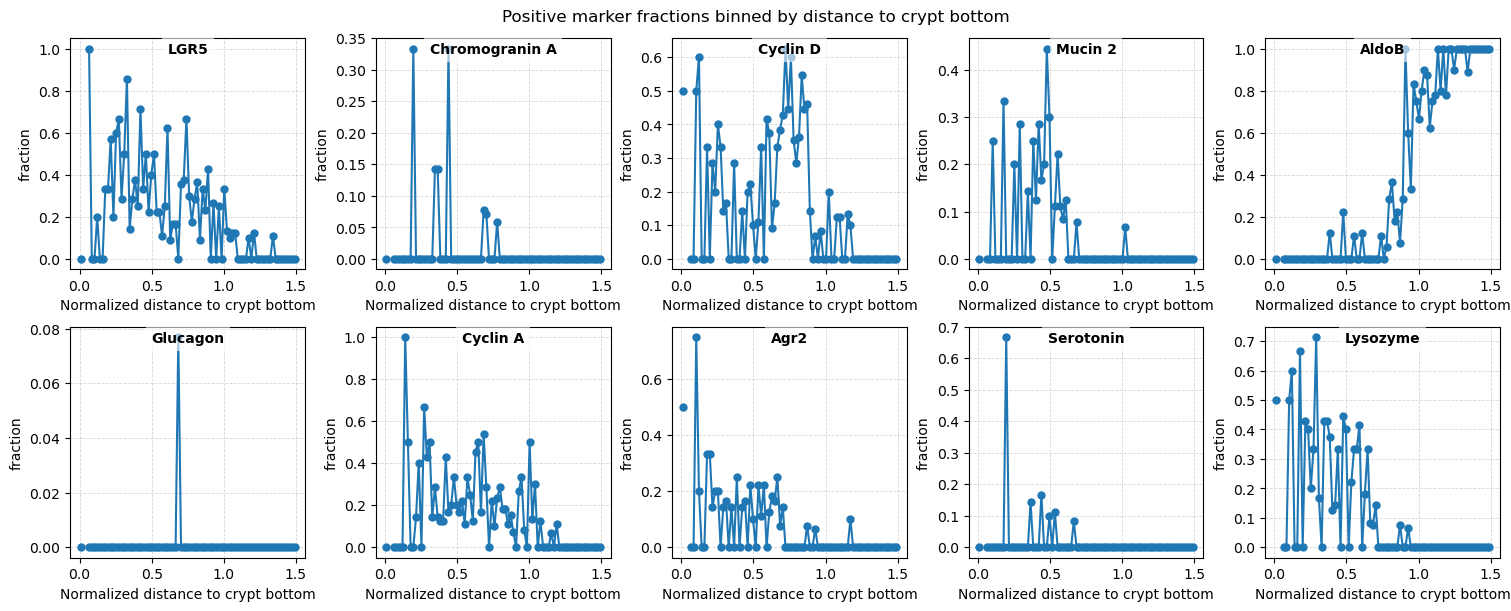

In [59]:
import matplotlib.pyplot as plt

M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers, num_pos_per_bin[i,:]/num_cells_per_bin, marker='o', linewidth=1.5, markersize=5)

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("fraction")

plt.suptitle("Positive marker fractions binned by distance to crypt bottom")
plt.show()


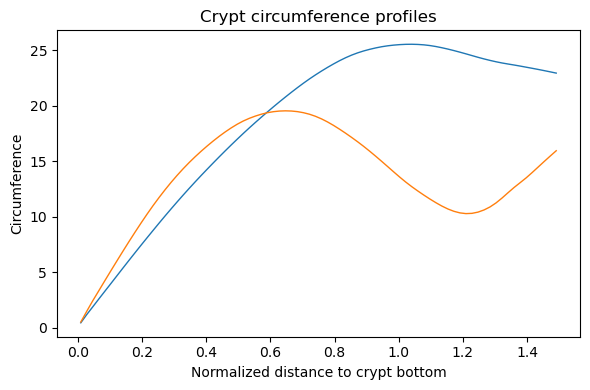

In [60]:
plt.figure(figsize=(6, 4))

for i in range(crypt_circumferences.shape[0]):
    plt.plot(bin_centers, crypt_circumferences[i], linewidth=1.0)

plt.xlabel("Normalized distance to crypt bottom")
plt.ylabel("Circumference")
plt.title("Crypt circumference profiles")
plt.tight_layout()
plt.show()

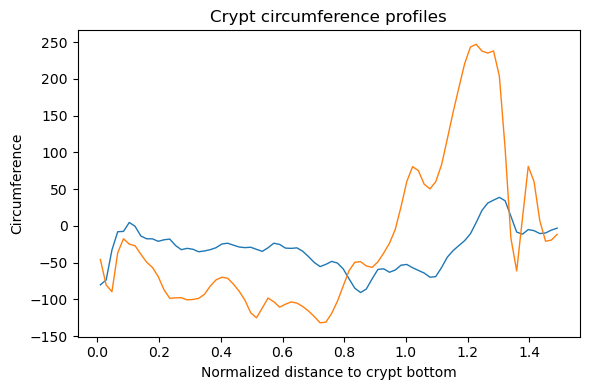

In [61]:
plt.figure(figsize=(6, 4))

for i in range(crypt_circumferences.shape[0]):
    plt.plot(bin_centers, np.gradient(np.gradient(crypt_circumferences[i],bin_centers), bin_centers), linewidth=1.0)

plt.xlabel("Normalized distance to crypt bottom")
plt.ylabel("Circumference")
plt.title("Crypt circumference profiles")
plt.tight_layout()
plt.show()

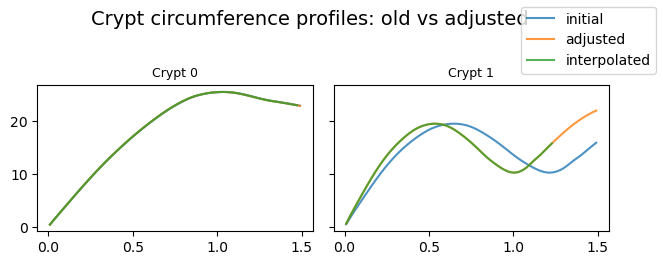

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import math


n_crypts = crypt_circumferences.shape[0]

# --- choose subplot grid ---
n_cols = int(np.ceil(np.sqrt(n_crypts)))
n_rows = int(np.ceil(n_crypts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5*n_cols, 2.8*n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)  # flatten in case of 2D grid

for i in range(n_crypts):
    ax = axes[i]

    # plot old
    ax.plot(bin_centers, crypt_circumferences[i], linewidth=1.5, alpha=0.8, label="initial")
    ax.plot(bin_centers, crypt_circumferences_adj[i], linewidth=1.5, alpha=0.8, label="adjusted")
    ax.plot(bin_centers, crypt_circumferences_int[i], linewidth=1.5, alpha=0.8, label="interpolated")

    ax.set_title(f"Crypt {i}", fontsize=9)

# hide unused subplots
for k in range(n_crypts, len(axes)):
    axes[k].axis("off")

# global labels
fig.suptitle("Crypt circumference profiles: old vs adjusted", fontsize=14)

# single legend (from first axis)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


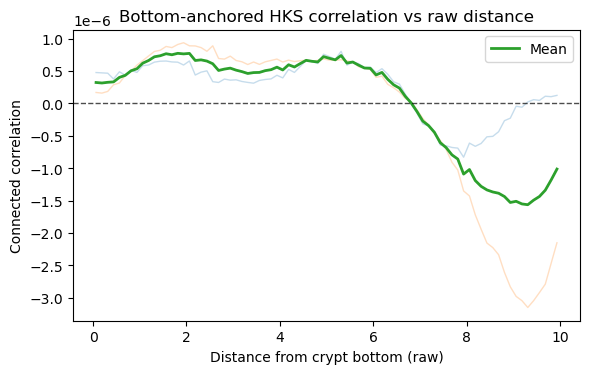

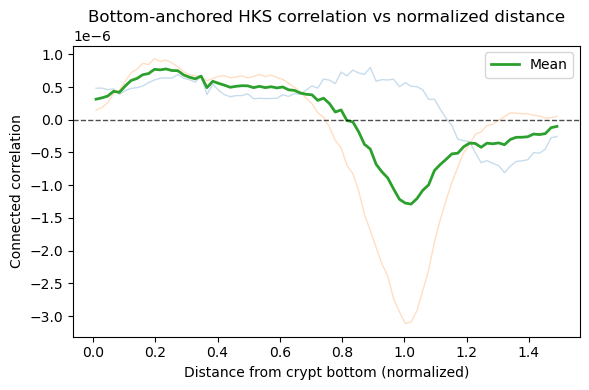

In [63]:
# -------- Figure 1: RAW distance --------
plt.figure(figsize=(6, 4))

for i in range(corrs_raw.shape[0]):
    plt.plot(r_centers, corrs_raw[i], alpha=0.25, linewidth=1.0)

mean_raw = np.nanmean(corrs_raw, axis=0)
plt.plot(r_centers, mean_raw, linewidth=2.0, label="Mean")
plt.axhline(0.0, linestyle="--", linewidth=1.0, color="black", alpha=0.7)

plt.xlabel("Distance from crypt bottom (raw)")
plt.ylabel("Connected correlation")
plt.title("Bottom-anchored HKS correlation vs raw distance")
plt.legend()
plt.tight_layout()
plt.show()


# -------- Figure 2: NORMALIZED distance --------
plt.figure(figsize=(6, 4))

for i in range(corrs_norm.shape[0]):
    plt.plot(s_centers, corrs_norm[i], alpha=0.25, linewidth=1.0)

mean_norm = np.nanmean(corrs_norm, axis=0)
plt.plot(s_centers, mean_norm, linewidth=2.0, label="Mean")
plt.axhline(0.0, linestyle="--", linewidth=1.0, color="black", alpha=0.7)

plt.xlabel("Distance from crypt bottom (normalized)")
plt.ylabel("Connected correlation")
plt.title("Bottom-anchored HKS correlation vs normalized distance")
plt.legend()
plt.tight_layout()
plt.show()



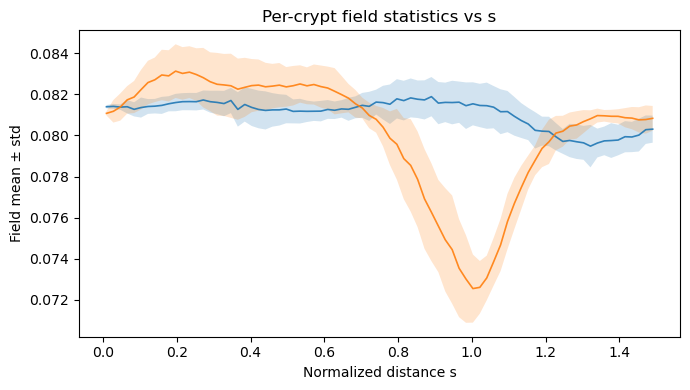

In [64]:
plt.figure(figsize=(7, 4))

for j in range(curv_mean.shape[0]):
    x = bin_centers
    y = curv_mean[j]
    ylo = y - curv_std[j]
    yhi = y + curv_std[j]

    plt.plot(x, y, linewidth=1.2, alpha=0.9)
    plt.fill_between(x, ylo, yhi, alpha=0.2)

plt.xlabel("Normalized distance s")
plt.ylabel("Field mean ± std")
plt.title("Per-crypt field statistics vs s")
plt.tight_layout()
plt.show()